# Global QFI of a damped/pumped bosonic mode — method comparison

A single bosonic mode with
$$
\partial_t \rho = -i[H,\rho] + \mathcal{D}[L_1]\rho + \mathcal{D}[L_2]\rho,
\quad
H = \epsilon\, a^\dagger a,
\quad
L_1=\sqrt{\gamma_\uparrow}\,a^\dagger,
\quad
L_2=\sqrt{\gamma_\downarrow}\,a .
$$

We estimate the **global quantum Fisher information** $I(\gamma_\uparrow, t)$ for sensing the
pump rate $\gamma_\uparrow$ with three methods and compare them:

| curve | method | where |
|-------|--------|-------|
| **Exact analytical** | closed-form Keldysh result (ground truth) | `dho.analytical.qfi_keldysh` |
| **Exact numerical** | finite-difference deformed (two-copy) Liouvillian | `dho.exact_numerical.global_qfi_deformed` |
| **Semiclassical** | Keldysh stochastic (saddle-point) trajectories, with a shaded $\pm\sigma$ error band | `dho.semiclassical.semiclassical_qfi_trajectories` |

All *computation* lives in the **`dho/` package** next to this notebook; all *plotting*
lives in this notebook, so the figures can be adjusted without touching the package.

In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# Repository-wide SciencePlots figure style (../plotstyle.py): REVTeX geometry,
# Computer Modern at 10 pt, outward ticks.  Everything else about the figures is
# defined in this notebook — the dho package computes, it does not plot.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from plotstyle import COLUMN_WIDTH, TEXT_WIDTH, PALETTE, figsize, limit_ticks, use_style

use_style()          # use_style(latex=False) → same look without a LaTeX install

# The runner package lives in ./dho next to this notebook.
from dho import run_comparison
from dho.meanfield import exact_mean_a, sc_trajectories_alpha

## Parameter sets

Edit the four dictionaries below — each becomes one panel. `run_comparison` fills in the
rest (defaults shown in comments): `tmax = 20/Δ` (≈ 20 relaxation times, enough to reach the
linear-in-$t$ plateau), the semiclassical step `dt_sc = 0.05`, and an auto-sized Fock
truncation for the exact-numerical engine. Any key can be overridden per set, e.g.
`dict(gamma_up=0.9, n_0=10.0, N_traj=40000, tmax=150.0)`.

> **Feasibility.** The exact-numerical (deformed-Liouvillian) engine needs a Fock cutoff
> $N \gtrsim 6\max(n_0, n_{ss})$ and builds an $N^2$-dimensional sparse superoperator, so it is
> skipped (curve omitted) when the auto-sized $N$ exceeds `max_fock` (default 120). The
> semiclassical and analytical curves have no such limit.

In [3]:
# ── Shared knobs ─────────────────────────────────────────────────────────────
GAMMA_DOWN = 1.0      # decay rate γ↓ — sets the time unit
EPSILON    = 1.0      # oscillator frequency ω  (=1 ⟹ ωt = t on the plots)
N_TRAJ     = 100000    # semiclassical trajectories (↑ to tighten the error band)
SEED       = 67

DEFAULTS = dict(gamma_down=GAMMA_DOWN, epsilon=EPSILON, N_traj=N_TRAJ, seed=SEED,
                dt_sc=0.01, delta=1e-5, max_fock=200, progress=True)

# ── Four (γ↑/γ↓, n₀) parameter sets → the four panels (row-major) ─────────────
PARAM_SETS = [
    dict(gamma_up=0.1 * GAMMA_DOWN, n_0=1.0),    # top-left
    #dict(gamma_up=0.9 * GAMMA_DOWN, n_0=1.0),    # top-right
    #dict(gamma_up=0.1 * GAMMA_DOWN, n_0=10.0),   # bottom-left
    dict(gamma_up=0.8 * GAMMA_DOWN, n_0=10.0),   # bottom-right
]

## Comparison figure

Each panel plots the QFI *rate* $I(\gamma_\uparrow,t)/t$ on a log time axis (so the long-time
limit $\gamma_\downarrow/(\gamma_\uparrow\Delta)$, $\Delta=\gamma_\downarrow-\gamma_\uparrow$,
appears as a horizontal asymptote). The semiclassical curve carries a shaded $\pm\sigma$
band from its finite-sample (power-sum) error. The whole figure — sizes, colours, legends, limits — is built in the next cell, so
edit it there; set `RATE = False` at the top of it to plot $I(\gamma_\uparrow,t)$ directly.

In [4]:
# Compute the three QFI curves for every parameter set (per-set keys override DEFAULTS).
panels = [run_comparison(**{**DEFAULTS, **p}) for p in PARAM_SETS]

SC trajectories:   0%|          | 0/11111 [00:00<?, ?it/s]

SC trajectories:   0%|          | 0/50000 [00:00<?, ?it/s]

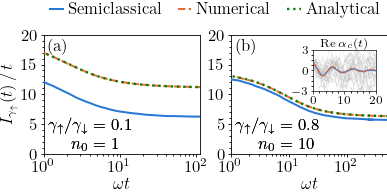

$\gamma_\uparrow/\gamma_\downarrow=0.1$, $n_0=1$:  n_ss=0.111  tmax=111.1  exact Fock N=20  |  I/t at t_max: sc=6.244, analytic=11.200
$\gamma_\uparrow/\gamma_\downarrow=0.8$, $n_0=10$:  n_ss=4.000  tmax=500.0  exact Fock N=97  |  I/t at t_max: sc=5.687, analytic=6.325


In [5]:
# ═══ Figure knobs — everything about the comparison figure is set right here ═══
RATE       = True     # plot I/t (True) or I(t) (False)
BAND_SIGMA = 1.0      # shaded semiclassical band is ±BAND_SIGMA·stderr
SAVEPATH   = "qfi_two_panel_comparison_dho.pdf"   # None → don't write a file
TOP_STRIP  = 0.06     # fraction of the canvas height reserved for the top legend
W_PAD      = 0.0      # horizontal gap between panels, in font-size units (0 = tightest)
HEADROOM   = 1.18     # y limit = HEADROOM × largest value drawn (room for the label)
LABEL_LOC  = "lower left"   # panel corner the parameter label is pinned to
LABEL_ANCHOR = (0.025, 0.025)  # that corner in axes coords; e.g. (-0.03, -0.05) pushes it further out
LABEL_LINESKIP = -4.0      # extra space between the label lines, in pt (negative = tighter)
XLABEL     = r"$\omega t$"
PANEL_TAGS   = ["(a)", "(b)", "(c)", "(d)"]  # corner tag per panel ([] -> none)
PANEL_TAG_XY = (0.03, 0.97)                  # tag position in axes fractions

# ── Inset: real part of the semiclassical vs exact <a(t)> diagnostic ─────────
INSET_PANEL  = -1        # panel index that carries the inset (None -> no inset)
INSET_RECT   = [0.525, 0.525, 0.4, 0.35]   # [x0, y0, w, h] in axes fractions
INSET_FONT   = 7         # pt - the only text below BASE_FONTSIZE in the figure
INSET_NTRAJ  = 400       # trajectories averaged for the inset mean
INSET_SHOW   = 20        # single trajectories drawn behind it (0 -> none)
INSET_TMAX   = 20.0      # inset time window
INSET_ALPHA0 = 1.0       # coherent initial state of the diagnostic
YLABEL     = r"$I_{\gamma_\uparrow}(t)\,/\,t$" if RATE else r"$I(\gamma_\uparrow,\,t)$"

# One entry per curve: colour + line style (so the series never rely on colour
# alone) + the legend text.  Reorder/rename freely.
STYLE = {
    "sc":       dict(color=PALETTE[0], ls="-",  lw=1.2, label="Semiclassical"),
    "exact":    dict(color=PALETTE[1], ls="--", lw=1.2, label="Numerical"),
    "analytic": dict(color=PALETTE[2], ls=":",  lw=1.4, label="Analytical"),
}

# Both panels together span exactly one REVTeX column; use TEXT_WIDTH for a
# full-width figure*.  ratio = height / width of the whole canvas.
FIGSIZE = figsize(COLUMN_WIDTH if len(panels) <= 2 else TEXT_WIDTH, ratio=0.70)


def as_xy(times, qfi):
    """(t, I/t) with t=0 dropped, or (t, I) when RATE is False."""
    t, q = np.asarray(times), np.asarray(qfi)
    if not RATE:
        return t, q
    m = t > 0
    return t[m], q[m] / t[m]


def aligned_label(label):
    """Stack "$a=1$, $b=2$" on two lines with the = signs aligned (needs LaTeX)."""
    parts = [p.strip().strip("$") for p in label.split(",")]
    if not plt.rcParams["text.usetex"] or not all("=" in p for p in parts):
        return "\n".join(f"${p}$" for p in parts)
    rows = [r"%s &= %s" % tuple(p.split("=", 1)) for p in parts]
    sep = r"\\[%gpt]" % LABEL_LINESKIP      # LaTeX line skip between the rows
    return r"$\begin{aligned}" + sep.join(rows) + r"\end{aligned}$"


fig, axes = plt.subplots(1, len(panels), figsize=(0.5 * TEXT_WIDTH, TEXT_WIDTH * 0.25), squeeze=False)
axes = axes.ravel()
pos_idx = 0
for ax, panel in zip(axes, panels):
    y_max = 0.0

    # ── Semiclassical mean + shaded ±σ band ──────────────────────────────────
    sc = panel["sc"]
    t_sc, y_sc = as_xy(sc["times"], sc["qfi"])
    _, y_lo = as_xy(sc["times"], sc["qfi"] - BAND_SIGMA * sc["qfi_stderr"])
    _, y_hi = as_xy(sc["times"], sc["qfi"] + BAND_SIGMA * sc["qfi_stderr"])
    ax.fill_between(t_sc, y_lo, y_hi, color=STYLE["sc"]["color"], alpha=0.25, lw=0, zorder=1)
    ax.plot(t_sc, y_sc, zorder=3, **STYLE["sc"])
    y_max = max(y_max, y_sc.max(), y_hi.max())

    # ── Exact numerical (absent when the Fock truncation was infeasible) ─────
    if panel.get("exact") is not None:
        t_ex, y_ex = as_xy(panel["exact"]["times"], panel["exact"]["qfi"])
        ax.plot(t_ex, y_ex, zorder=4, **STYLE["exact"])
        y_max = max(y_max, y_ex.max())

    # ── Exact analytical (ground truth) ──────────────────────────────────────
    t_an, y_an = as_xy(panel["analytic"]["times"], panel["analytic"]["qfi"])
    ax.plot(t_an, y_an, zorder=5, **STYLE["analytic"])
    y_max = max(y_max, y_an.max())

    # ── Axes cosmetics ───────────────────────────────────────────────────────
    ax.set_xlim(1, panel["tmax"])          # x axis keeps its own 0 tick
    ax.set_xscale("log")                   
    ax.set_ylim(0, 20)       # QFI is non-negative; nothing clipped
    ax.set_xlabel(XLABEL)
    limit_ticks(ax)                        # at most 5 tick labels per axis
    ax.tick_params(labelleft=True, labelbottom=True)

    # Parameter set as a handle-less legend inside the panel (instead of a title).
    ax.add_artist(ax.legend([plt.Line2D([], [], lw=0)], [aligned_label(panel["label"])],
                            loc=LABEL_LOC, bbox_to_anchor=LABEL_ANCHOR, frameon=False,
                            handlelength=0, handletextpad=0,
                            borderpad=0, borderaxespad=0))

    # (a), (b), ... in the upper-left corner of the panel.
    if pos_idx < len(PANEL_TAGS):
        ax.text(*PANEL_TAG_XY, PANEL_TAGS[pos_idx], transform=ax.transAxes,
                ha="left", va="top")
    pos_idx += 1

axes[0].set_ylabel(YLABEL)

# ═══ Inset ═══════════════════════════════════════════════════════════════════
# Re<a(t)>: the trajectory mean (blue) must track the analytic exact mean
# (orange dashed); grey lines are single trajectories.  Uses the host panel's
# own rates, so the inset always matches the QFI curves it sits in.
if INSET_PANEL is not None:
    host, hp = axes[INSET_PANEL], panels[INSET_PANEL]
    t_in, trajs_in = sc_trajectories_alpha(
        N_traj=INSET_NTRAJ, epsilon=hp["epsilon"], gamma_up=hp["gamma_up"],
        gamma_down=hp["gamma_down"], tmax=INSET_TMAX, nt=400,
        alpha_0=INSET_ALPHA0, seed=67,
    )
    a_in = exact_mean_a(INSET_ALPHA0, hp["epsilon"], hp["gamma_up"], hp["gamma_down"], t_in)

    axin = host.inset_axes(INSET_RECT)
    for k in range(INSET_SHOW):
        axin.plot(t_in, trajs_in[k].real, color="silver", lw=0.2, alpha=0.5, zorder=1)
    axin.plot(t_in, trajs_in.mean(axis=0).real, color=STYLE["sc"]["color"], lw=0.8, zorder=3)
    axin.plot(t_in, a_in.real, color=STYLE["exact"]["color"], lw=0.8, ls="--", zorder=4)
    axin.set_xlim(0, INSET_TMAX)
    axin.set_ylim(-3.0, 3.0)
    axin.set_title(r"$\mathrm{Re}\,\alpha_c(t)$", fontsize=INSET_FONT, pad=1.5)
    axin.tick_params(labelsize=INSET_FONT, pad=1, length=1.5, width=0.4)
    for spine in axin.spines.values():
        spine.set_linewidth(0.4)
    limit_ticks(axin, 3)     # 3 tick labels per axis is all an inset can carry

# Shared curve legend in one row on top.  The strip is reserved *inside* the
# canvas: the figure is saved with a standard bbox (to keep the exact column
# width), so anything placed outside the canvas would be cut off.
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 1 - TOP_STRIP), w_pad=W_PAD)
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False,
           bbox_to_anchor=(0.55, 1.0), columnspacing=1.0, borderaxespad=0.1)

if SAVEPATH:
    fig.savefig(SAVEPATH)   # no bbox_inches="tight": that would crop the canvas
plt.show()

for p in panels:
    N = p["exact"]["N"] if p["exact"] is not None else "skipped"
    print(f"{p['label']}:  n_ss={p['n_ss']:.3f}  tmax={p['tmax']:.1f}  "
          f"exact Fock N={N}  |  I/t at t_max: "
          f"sc={p['sc']['qfi'][-1]/p['sc']['times'][-1]:.3f}, "
          f"analytic={p['analytic']['qfi'][-1]/p['analytic']['times'][-1]:.3f}")

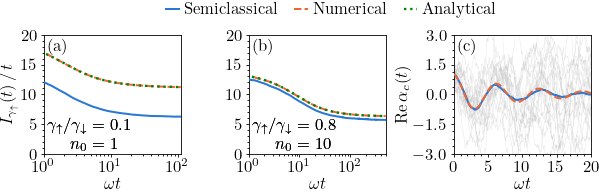

In [11]:
# ═══ Same comparison figure, but the (b) inset promoted to its own panel (c) ══
# Everything is inherited from the cell above (RATE, STYLE, as_xy, aligned_label,
# the INSET_* diagnostic knobs, ...) — only the layout changes: two QFI panels
# plus a third, full-size panel showing the Re α_c(t) diagnostic on the right.
SAVEPATH3 = "qfi_three_panel_comparison_dho.pdf"   # None → don't write a file
DIAG_PANEL = -1        # which parameter set the diagnostic rates come from
DIAG_YLABEL = r"$\mathrm{Re}\,\alpha_c(t)$"
W_PAD = 0.5

n_ax = len(panels) + 1
fig, axes = plt.subplots(1, n_ax, figsize=(0.25 * TEXT_WIDTH * n_ax, TEXT_WIDTH * 0.25),
                         squeeze=False)
axes = axes.ravel()
pos_idx = 0
for ax, panel in zip(axes, panels):
    y_max = 0.0

    # ── Semiclassical mean + shaded ±σ band ──────────────────────────────────
    sc = panel["sc"]
    t_sc, y_sc = as_xy(sc["times"], sc["qfi"])
    _, y_lo = as_xy(sc["times"], sc["qfi"] - BAND_SIGMA * sc["qfi_stderr"])
    _, y_hi = as_xy(sc["times"], sc["qfi"] + BAND_SIGMA * sc["qfi_stderr"])
    ax.fill_between(t_sc, y_lo, y_hi, color=STYLE["sc"]["color"], alpha=0.25, lw=0, zorder=1)
    ax.plot(t_sc, y_sc, zorder=3, **STYLE["sc"])
    y_max = max(y_max, y_sc.max(), y_hi.max())

    # ── Exact numerical (absent when the Fock truncation was infeasible) ─────
    if panel.get("exact") is not None:
        t_ex, y_ex = as_xy(panel["exact"]["times"], panel["exact"]["qfi"])
        ax.plot(t_ex, y_ex, zorder=4, **STYLE["exact"])
        y_max = max(y_max, y_ex.max())

    # ── Exact analytical (ground truth) ──────────────────────────────────────
    t_an, y_an = as_xy(panel["analytic"]["times"], panel["analytic"]["qfi"])
    ax.plot(t_an, y_an, zorder=5, **STYLE["analytic"])
    y_max = max(y_max, y_an.max())

    # ── Axes cosmetics ───────────────────────────────────────────────────────
    ax.set_xlim(1, panel["tmax"])          # x axis keeps its own 0 tick
    ax.set_xscale("log")
    ax.set_ylim(0, 20)       # QFI is non-negative; nothing clipped
    ax.set_xlabel(XLABEL)
    limit_ticks(ax)                        # at most 5 tick labels per axis
    ax.tick_params(labelleft=True, labelbottom=True)

    # Parameter set as a handle-less legend inside the panel (instead of a title).
    ax.add_artist(ax.legend([plt.Line2D([], [], lw=0)], [aligned_label(panel["label"])],
                            loc=LABEL_LOC, bbox_to_anchor=LABEL_ANCHOR, frameon=False,
                            handlelength=0, handletextpad=0,
                            borderpad=0, borderaxespad=0))

    # (a), (b), ... in the upper-left corner of the panel.
    if pos_idx < len(PANEL_TAGS):
        ax.text(*PANEL_TAG_XY, PANEL_TAGS[pos_idx], transform=ax.transAxes,
                ha="left", va="top")
    pos_idx += 1

axes[0].set_ylabel(YLABEL)

# ═══ Panel (c): the former inset, at full size ═══════════════════════════════
# Re α_c(t): the trajectory mean (blue) must track the analytic exact mean
# (orange dashed); grey lines are single trajectories.  Uses the diagnostic
# panel's own rates, so it always matches the QFI curves next to it.
axd, hp = axes[-1], panels[DIAG_PANEL]
t_in, trajs_in = sc_trajectories_alpha(
    N_traj=INSET_NTRAJ, epsilon=hp["epsilon"], gamma_up=hp["gamma_up"],
    gamma_down=hp["gamma_down"], tmax=INSET_TMAX, nt=400,
    alpha_0=INSET_ALPHA0, seed=67,
)
a_in = exact_mean_a(INSET_ALPHA0, hp["epsilon"], hp["gamma_up"], hp["gamma_down"], t_in)

for k in range(INSET_SHOW):
    axd.plot(t_in, trajs_in[k].real, color="silver", lw=0.2, alpha=0.5, zorder=1)
axd.plot(t_in, trajs_in.mean(axis=0).real, color=STYLE["sc"]["color"], lw=1.2, zorder=3)
axd.plot(t_in, a_in.real, color=STYLE["exact"]["color"], lw=1.2, ls="--", zorder=4)
axd.set_xlim(0, INSET_TMAX)
axd.set_ylim(-3.0, 3.0)
axd.set_xlabel(XLABEL)
axd.set_ylabel(DIAG_YLABEL)
limit_ticks(axd)
if pos_idx < len(PANEL_TAGS):
    axd.text(*PANEL_TAG_XY, PANEL_TAGS[pos_idx], transform=axd.transAxes,
             ha="left", va="top")

# Shared curve legend in one row on top.  The strip is reserved *inside* the
# canvas: the figure is saved with a standard bbox (to keep the exact column
# width), so anything placed outside the canvas would be cut off.
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 1 - TOP_STRIP), w_pad=W_PAD)
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False,
           bbox_to_anchor=(0.55, 1.0), columnspacing=1.0, borderaxespad=0.1)

if SAVEPATH3:
    fig.savefig(SAVEPATH3)   # no bbox_inches="tight": that would crop the canvas
plt.show()


## Diagnostic: exact $\langle a(t)\rangle$ vs semiclassical $\langle\alpha_c(t)\rangle$

A sanity check on the drift/noise of the SDE stepper. The equation of motion for $\langle a\rangle$
is linear, so the exact result is analytic, $\langle a(t)\rangle=\alpha_0 e^{(-i\epsilon-\Delta/2)t}$,
and the trajectory mean must converge to it (individual trajectories scatter around it due to the
bath noise). Uses `dho.meanfield`.

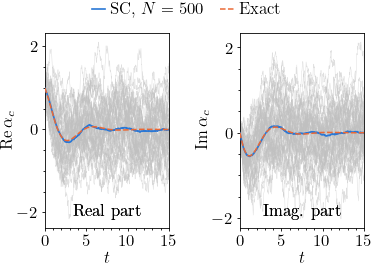

Max |SC mean - exact| / |α₀| = 0.0852  (sampling error from 500 trajectories)


In [72]:
# Coherent initial state |α₀⟩ ⟹ ⟨a(0)⟩ = α₀ ≠ 0 (a non-trivial mean to track).
gamma_up, gamma_down, epsilon, alpha_0 = 0.1, 1.0, 1.0, 1.0
tmax_dyn, nt_dyn, N_traj_dyn, N_show = 15.0, 600, 500, 40

times_dyn, trajs = sc_trajectories_alpha(
    N_traj=N_traj_dyn, epsilon=epsilon, gamma_up=gamma_up, gamma_down=gamma_down,
    tmax=tmax_dyn, nt=nt_dyn, alpha_0=alpha_0, seed=0,
)
a_exact = exact_mean_a(alpha_0, epsilon, gamma_up, gamma_down, times_dyn)
sc_mean = trajs.mean(axis=0)

# Both panels side by side, together spanning exactly one REVTeX column.  No
# sharey: each panel autoscales its own y range and keeps its own tick labels.
fig, axes = plt.subplots(1, 2, figsize=figsize(COLUMN_WIDTH, ratio=0.70))
for ax, part, ylabel, panel_label in zip(
    axes, [np.real, np.imag],
    [r"$\mathrm{Re}\,\alpha_c$", r"$\mathrm{Im}\,\alpha_c$"],
    ["Real part", "Imag. part"],
):
    for k in range(N_show):
        ax.plot(times_dyn, part(trajs[k]), color="silver", lw=0.3, alpha=0.5, zorder=1)
    ax.plot(times_dyn, part(sc_mean), color=PALETTE[0], lw=1.0, zorder=3,
            label=rf"SC, $N={N_traj_dyn}$")
    ax.plot(times_dyn, part(a_exact), color=PALETTE[1], lw=0.9, ls="--", zorder=4,
            label="Exact")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, tmax_dyn)   # own 0 tick on the x axis
    limit_ticks(ax)            # at most 5 tick labels per axis
    # Panel name as a handle-less legend inside the panel, instead of a title.
    ax.add_artist(ax.legend([plt.Line2D([], [], lw=0)], [panel_label],
                            loc="lower center", frameon=False,
                            handlelength=0, handletextpad=0, borderpad=0.2))

# Shared curve legend in a row on top; the strip is reserved inside the canvas
# (the figures are saved with a standard bbox, so nothing outside it survives).
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False,
           bbox_to_anchor=(0.5, 1.0), columnspacing=1.0, borderaxespad=0.1)
plt.show()

print(f"Max |SC mean - exact| / |α₀| = "
      f"{np.max(np.abs(sc_mean - a_exact)) / abs(alpha_0):.4f}  "
      f"(sampling error from {N_traj_dyn} trajectories)")